# Modelling

Initial setup for modelling with randomforest, histgradientboosting and logisticregression and features. Currently the randomforest part of the notebook uses some memory, so 48GB of RAM is a good start, but the other parts of the training runs more easily.

Data output:
* [classifier.joblib](../data_generated/classifier.joblib) Trained model
* [cv_best_by_model.json](../data_generated/cv_best_by_model.json) best parameters


## Todo

- [x] Setup pipeline for testing various models
- [x] Test gradientboosting
- [x] Test logistic regression
- [ ] Add evalutation of model results
- [x] Add new features taredata, flow models, bløtbunnsdatabase ++
- [x] Check waveheight model


In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report


import geoutils as gu
from joblib import dump
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import RandomizedSearchCV

import json
import sys
sys.path.append("/home/jovyan/marint-naturkart-niva")
import subkart
import importlib

## Terrain features

In [2]:
county_codes = [
    #"03_Oslo",
    #"11_Rogaland",
    #"18_Nordland",
    #"21_Svalbard",
    "15_More_og_Romsdal",
    #"31_Ostfold",
    #"32_Akershus",
    #"39_Vestfold",
    "46_Vestland",
    "50_Trondelag",
    #"55_Troms",
    #"56_Finnmark",
]

county_files = []
for code in county_codes:
    county_files.append(
        f"gs://niva-geodata/MarintNaturKart/Basisdata_{code}_25833_Dybdedata_Dybdeareal.geo.parquet"
    )

gdfs = [gpd.read_parquet(path) for path in county_files]

gdf_depth = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))
crs = gdf_depth.crs
del gdfs

In [3]:
gdf_depth = subkart.features.depth_preprocess(gdf_depth)


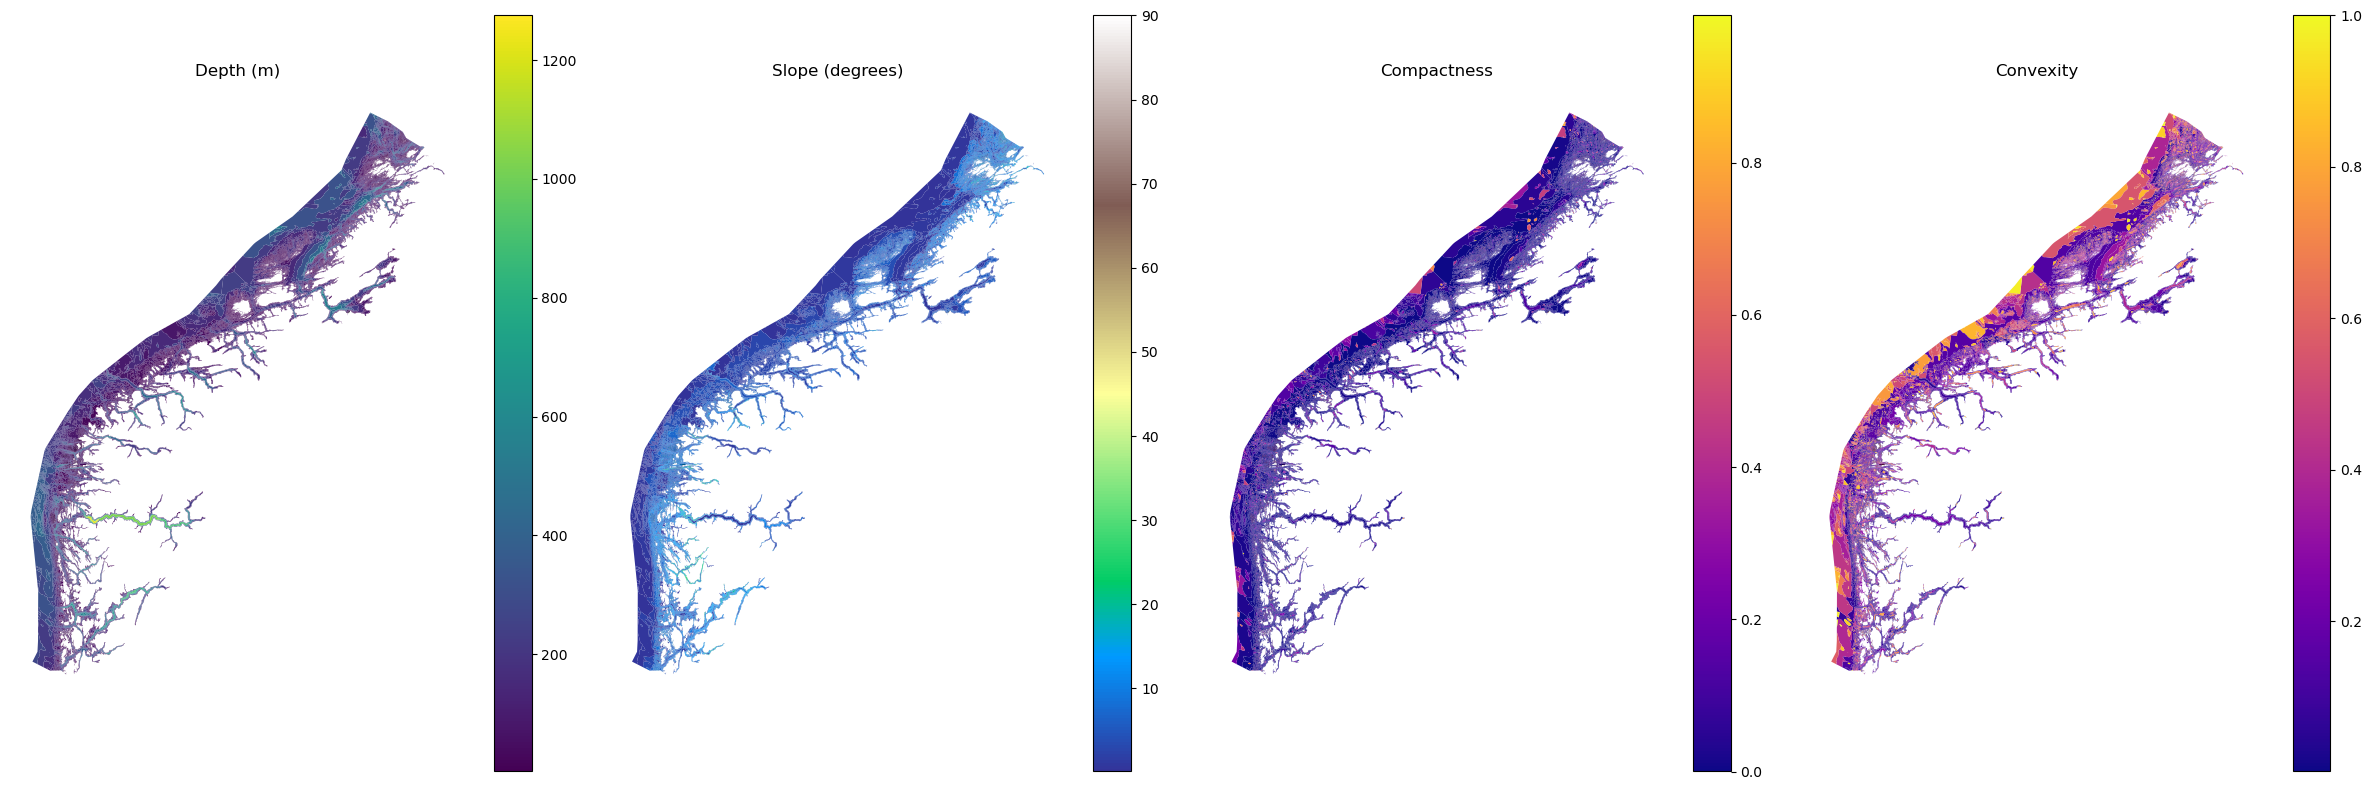

In [4]:
subkart.utils.plot_terrain_features(gdf_depth)

### Marine vanntyper features



In [5]:
marine_vanntyper = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/mdir/NyTypologi2022.geo.parquet").to_crs(gdf_depth.crs)

In [9]:
rasters, one_hot_types = subkart.features.build_basis_raster(gdf_depth, marine_vanntyper)

/opt/conda/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(
/opt/conda/lib/python3.13/site-packages/geoutils/raster/raster.py:1822: UserWarning: Setting default nodata -99999 to mask non-finite values found in the array, as no nodata value was defined.
  warnings.warn(


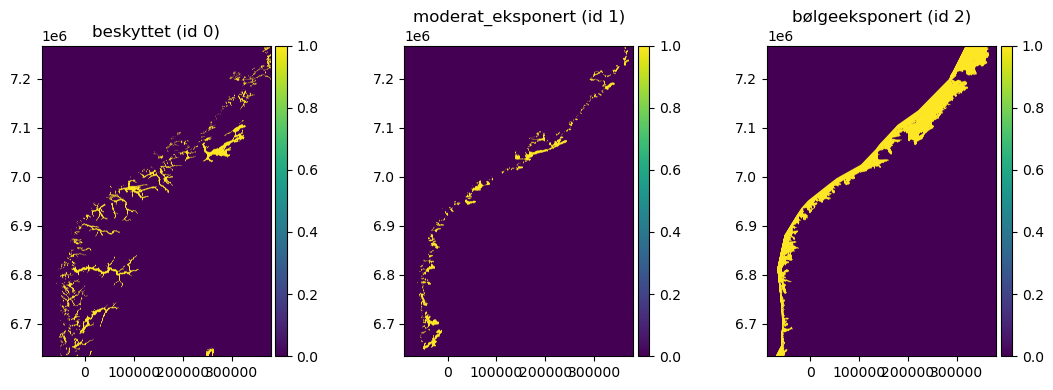

In [10]:
subkart.utils.plot_one_hot_vanntyper(one_hot_types, rasters[0].transform, crs, cols=3, rows=1)

In [11]:
features, valid_attrs = subkart.features.stack(rasters, one_hot_types)

del gdf_depth, marine_vanntyper

## Dataset for labels

Using NGU bunnsedimenter detaljert

In [12]:
gdf_bunn_full = gpd.read_parquet("gs://niva-geodata/MarintNaturKart/nisjedata-substrat-klassifisering_norge_latest_25833.geo.parquet")

In [13]:
gdf_bunn_full = gdf_bunn_full.dissolve(by="BunnType", as_index=False)
gdf_bunn_full["BunnType"].unique().tolist()

['blanding/uspesifisert', 'fastbunn', 'løsbunn']

In [15]:
gdf_bunn_full = gdf_bunn_full.to_crs(crs)
bunn_raster, valid_bunn = subkart.labelling.rasterize_bunn_type(gdf_bunn_full, rasters[0].shape[-2:], rasters[0].transform)
del gdf_bunn_full

In [16]:
valid = valid_attrs & valid_bunn

X = features[valid]
y = bunn_raster[valid].astype(np.uint8)  # labels: {0,1,2}

classes = np.array(list(subkart.labelling.BUNNTYPE_MAPPING.values()), dtype=np.uint8)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

class_weights = {int(c): float(weight) for c, weight in zip(classes, weights)}
# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Training

## Baseline

Train a quick baseline for each model

In [17]:
baseline_models = [
    HistGradientBoostingClassifier(random_state=42, class_weight=class_weights),
    RandomForestClassifier(n_jobs=2, class_weight=class_weights, random_state=42),
    LogisticRegression(max_iter=100000, class_weight=class_weights, random_state=42),
]
score = 0
for base_model in baseline_models:
    m = Pipeline([("model", base_model)])
    m.fit(X_train, y_train)
    val_score = m.score(X_val, y_val)
    print(f"Baseline {type(base_model).__name__} - "
            f"Train: {m.score(X_train, y_train):.4f}, Val: {val_score:.4f}")
    if val_score > score:
        score = val_score
        classifier = base_model

Baseline HistGradientBoostingClassifier - Train: 0.5664, Val: 0.5651
Baseline RandomForestClassifier - Train: 0.6009, Val: 0.5968


KeyboardInterrupt: 

## Random Search

Search through hyperparameters for each model, this can take some time

In [ ]:

search_spaces = [
    {
        "model": [RandomForestClassifier(n_jobs=2, class_weight=class_weights, random_state=42)],
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [10, 20],
        "model__min_samples_leaf": [4, 10],
        "model__min_samples_split": [5, 10],
        "model__max_features": ["sqrt", 0.5],
    },
    {
        "model": [HistGradientBoostingClassifier(random_state=42)],
        "model__learning_rate": [0.05, 0.1, 0.2],
        "model__max_depth": [None, 6, 12],
        "model__max_leaf_nodes": [31, 63, 127],
        "model__min_samples_leaf": [20, 50, 100],
        "model__l2_regularization": [0.0, 0.1, 1.0],
        "model__max_bins": [128, 255],
    },
    {
        "model": [LogisticRegression(max_iter=100000, class_weight=class_weights, random_state=42)],
        "model__C": [0.1, 1.0, 10.0],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs"],
    },
]
pipe = Pipeline([("model", RandomForestClassifier())])
random_search = RandomizedSearchCV(
    pipe, param_distributions=search_spaces, n_iter=80, cv=2, verbose=3, random_state=42
)
random_search.fit(X_train, y_train)

# Use the best model for downstream cells
classifier = random_search.best_estimator_.named_steps["model"]

cv = random_search.cv_results_
best_by_model = {}

for i, p in enumerate(cv["params"]):
    model_name = type(p["model"]).__name__
    score = float(cv["mean_test_score"][i])
    if (model_name not in best_by_model) or (score > best_by_model[model_name]["score"]):
        readable = {}
        for k, v in p.items():
            if k == "model":
                continue
            readable[k.split("__", 1)[1] if k.startswith("model__") else k] = v
        best_by_model[model_name] = {"score": score, "params": readable}

# Print summary
for name, info in best_by_model.items():
    print(f"{name}: mean_test_score={info['score']:.4f}, params={info['params']}")

# Dump summary to JSON
with open("../data_generated/cv_best_by_model.json", "w", encoding="utf-8") as f:
    json.dump(
        {name: {"score": info["score"], "params": info["params"]} for name, info in best_by_model.items()},
        f,
        indent=2
    )

classifier.fit(X_train, y_train)
print("Train accuracy:", classifier.score(X_train, y_train))
print("Validation accuracy:", classifier.score(X_val, y_val))

In [18]:
dump(classifier, "../data_generated/classifier.joblib")

['../data_generated/classifier.joblib']

depth: mean=0.096595, std=0.000596
slope: mean=0.068220, std=0.000464
vanntype_bølgeeksponert: mean=0.041214, std=0.000206
convexity: mean=0.035594, std=0.000412
vanntype_beskyttet: mean=0.023793, std=0.000171
compactness: mean=0.023399, std=0.000123
vanntype_moderat_eksponert: mean=0.016201, std=0.000267


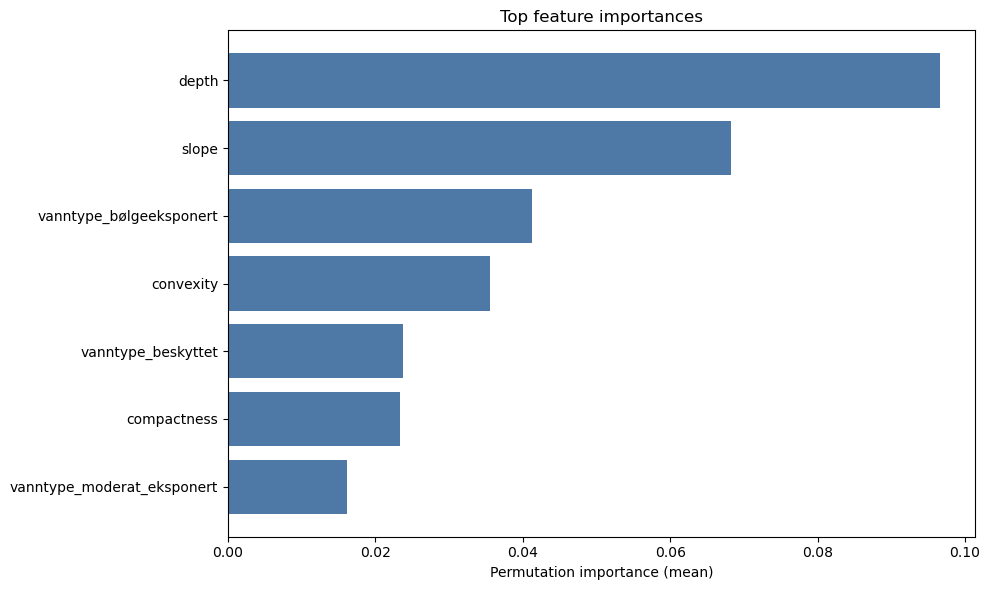

In [19]:
# Compute permutation importance for the best model on validation data
result = permutation_importance(
    classifier, X_val, y_val, n_repeats=5, random_state=42, n_jobs=2
)
_, id_type_map, _ = subkart.features.marine_type_map()
# Build feature names: terrain features + one-hot marine type features
terrain_features =  ["depth", "slope", "compactness", "convexity"]
vanntype_names = list(id_type_map.values())
feature_names = terrain_features + [f"vanntype_{name}" for name in vanntype_names]

# Sort features by importance
importances_mean = result.importances_mean
importances_std = result.importances_std
sorted_idx = np.argsort(importances_mean)[::-1]

# Print top 20 features
top_n = 20
for i in sorted_idx[:top_n]:
    print(f"{feature_names[i]}: mean={importances_mean[i]:.6f}, std={importances_std[i]:.6f}")

# Save full importance results to JSON
importance_dict = [
    {
        "feature": feature_names[i],
        "mean": float(importances_mean[i]),
        "std": float(importances_std[i]),
    }
    for i in sorted_idx
]


top_idx = sorted_idx[:top_n]
labels = [feature_names[i] for i in top_idx]
values = importances_mean[top_idx]

plt.figure(figsize=(10, 6))
plt.barh(labels[::-1], values[::-1], color="#4e79a7")
plt.xlabel("Permutation importance (mean)")
plt.title("Top feature importances")
plt.tight_layout()
plt.show()
